In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt




In [2]:
# Simulation parameters common to all cases:
Ntraj = 100000         # number of trajectories
stiffness = 1.

# Define functions for mu and its derivative given a slow time scale T_slow.
def mu(t, T_slow):
    tau = t / T_slow
    return tau  # linear function

def mu_prime(t, T_slow):
    return 1/T_slow  # constant derivative

# Theoretical density functions:
def p_ad(x, t, T_slow):
    # Instantaneous equilibrium (adiabatic) density.
    mu_val = mu(t, T_slow)
    return jnp.exp(-0.5 * stiffness*(x - mu_val)**2) / jnp.sqrt(1/stiffness*2 * jnp.pi)

def p_first_order(x, t, T_slow):
    # First order corrected density: p_ad * (1 - (1/T_slow)*mu_prime(t)*(x-mu(t)))
    mu_val = mu(t, T_slow)
    mu_p = mu_prime(t, T_slow)
    base = p_ad(x, t, T_slow)
    correction = 1 - (1/T_slow)  * stiffness* (x - mu_val)
    return base * correction

# Euler-Maruyama step for the overdamped SDE: dx = -[x - mu(t)] dt + sqrt(dt)*xi
def step(x, t, T_slow, key,dt):
    key, subkey = jax.random.split(key)
    xi = jax.random.normal(subkey, shape=x.shape)
    # Update: note that mu is computed with t and T_slow.
    x_new = x - stiffness*(x - mu(t, T_slow)) * dt + jnp.sqrt(2*dt) * xi
    return x_new, key

def simulate(T_slow, key, T_sim, dt):
    # Split key for initial sampling and simulation steps
    key, sample_key = jax.random.split(key)
    
    # Sample initial conditions from p_ad at t=0
    xi = jax.random.normal(sample_key, shape=(Ntraj,))
    x = xi / jnp.sqrt(stiffness)  # Since p_ad(t=0) is N(0, 1/stiffness)
    
    n_steps = int(T_sim/dt)
    t = 0.0
    keys = jax.random.split(key, n_steps)
    for i in range(n_steps):
        x, _ = step(x, t, T_slow, keys[i],dt)
        t += dt
    return x





CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


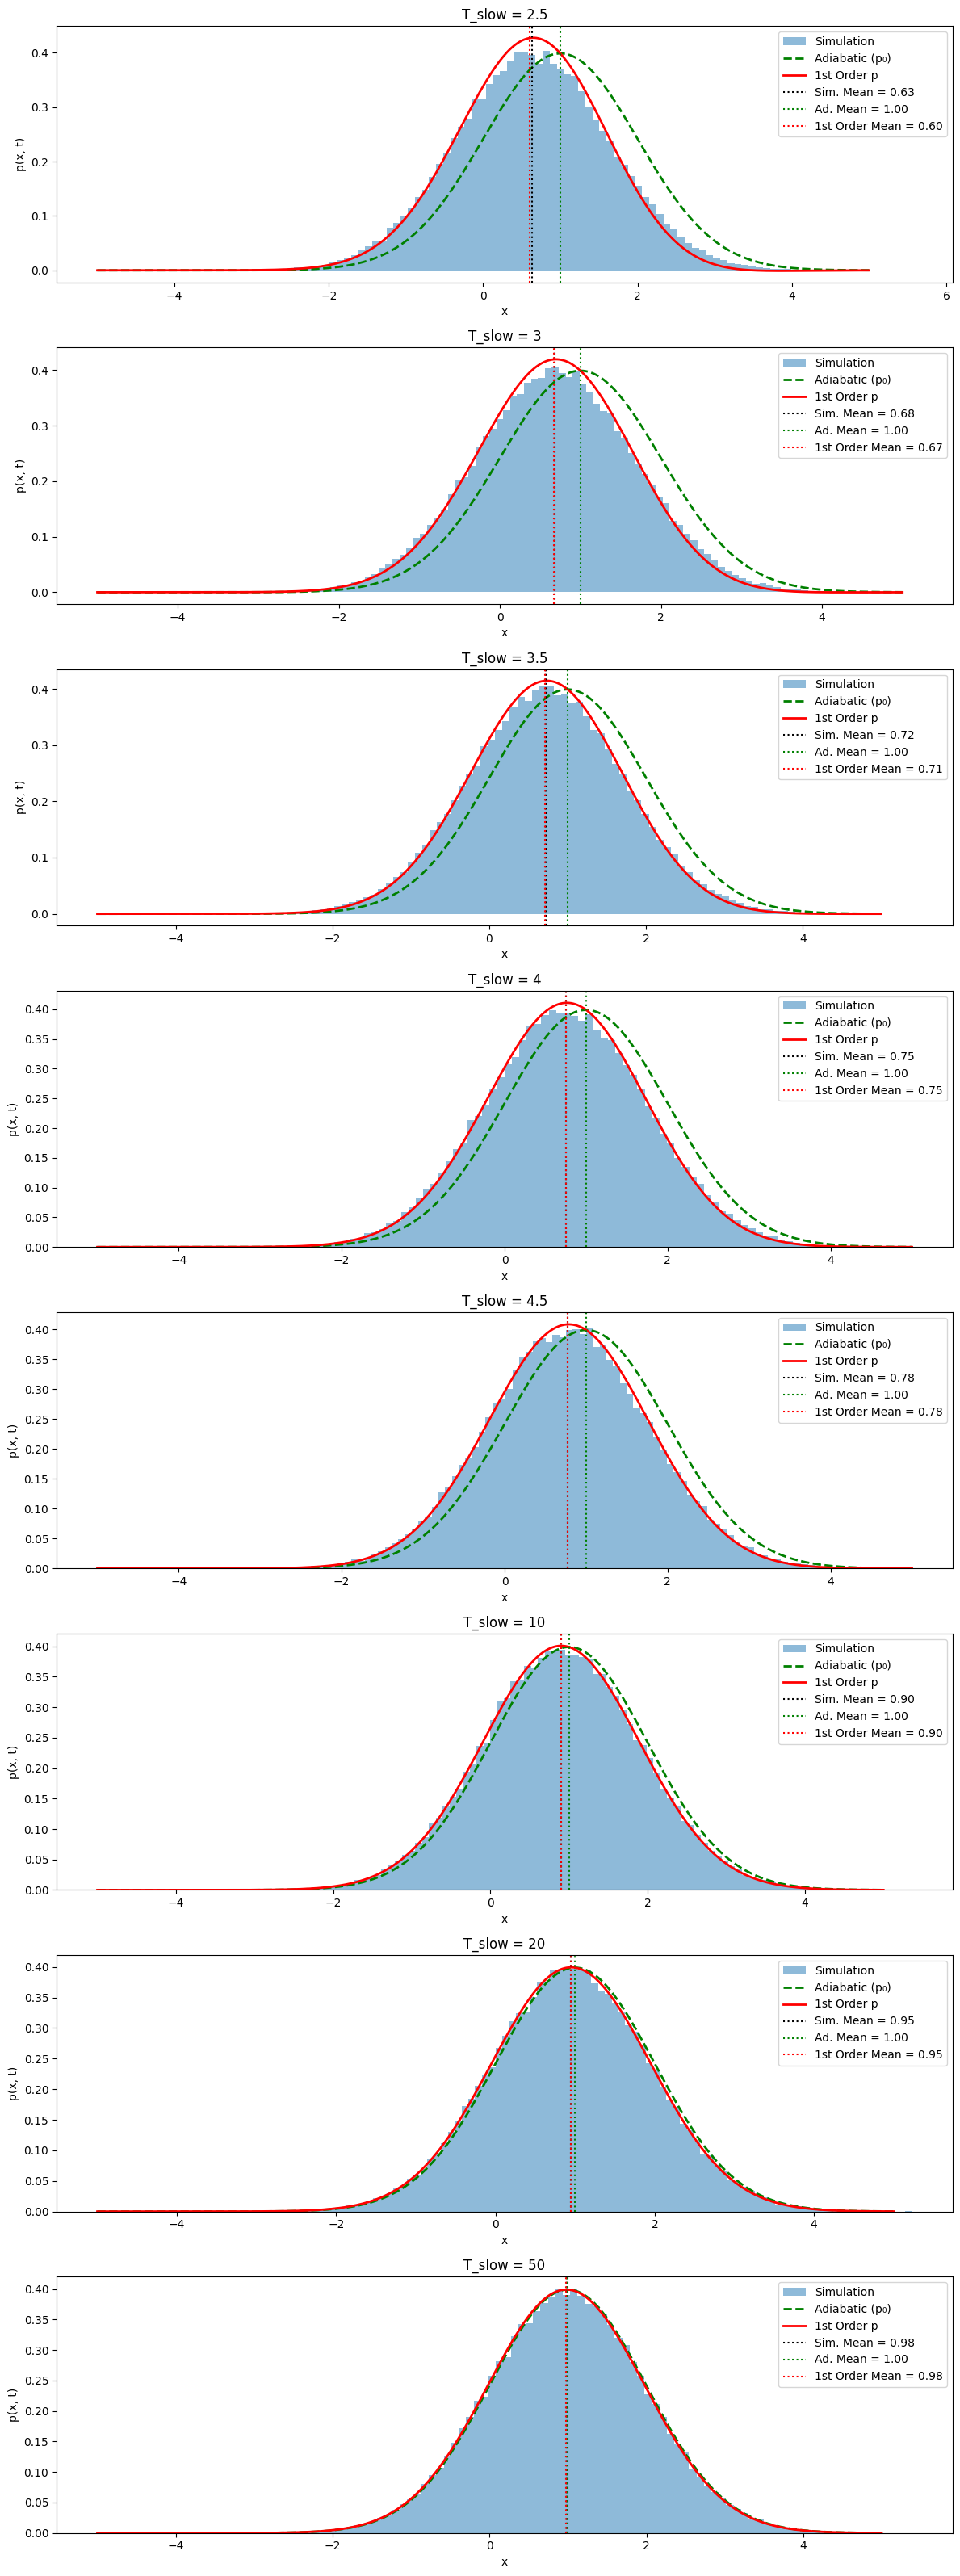

In [3]:
# Choose several slow time scales to test.
T_slow_list = [2.5,3,3.5,4,4.5,10,20,50]

# Set up a figure with subplots
n_plots = len(T_slow_list)  # 40 plots
fig, axes = plt.subplots(n_plots, 1, figsize=(12, 4*n_plots))
axes = axes.flatten()
key0 = jax.random.PRNGKey(0)


# x-grid for plotting theoretical curves.
x_grid = jnp.linspace(-5, 5, 400)


for idx, T_slow in enumerate(T_slow_list):
    key = jax.random.fold_in(key0, int(T_slow))
    T_sim = T_slow
    dt = 0.01
    x_final = simulate(T_slow, key,T_sim,dt)
    
    # Compute mean of samples
    mean_x = jnp.mean(x_final)
    
    # Compute theoretical means
    mean_ad = mu(T_slow, T_slow)  # Adiabatic mean
    p1_th = p_first_order(x_grid, T_slow, T_slow)
    dx = x_grid[1] - x_grid[0]
    mean_first = jnp.sum(x_grid * p1_th) * dx  # Expectation value using first order distribution
    
    
    # Compute theoretical densities at final_time
    p0_th = p_ad(x_grid, T_slow, T_slow)
    p1_th = p_first_order(x_grid, T_slow, T_slow)
    
    ax = axes[idx]
    ax.hist(x_final, bins=100, density=True, alpha=0.5, label='Simulation')
    ax.plot(x_grid, p0_th, 'g--', lw=2, label='Adiabatic (p₀)')
    ax.plot(x_grid, p1_th, 'r-', lw=2, label='1st Order p')
    ax.axvline(x=mean_x, color='k', linestyle=':', label=f'Sim. Mean = {mean_x:.2f}')
    ax.axvline(x=mean_ad, color='g', linestyle=':', label=f'Ad. Mean = {mean_ad:.2f}')
    ax.axvline(x=mean_first, color='r', linestyle=':', label=f'1st Order Mean = {mean_first:.2f}')
    ax.set_title(f"T_slow = {T_slow}")
    ax.set_xlabel("x")
    ax.set_ylabel("p(x, t)")
    ax.legend()

plt.tight_layout()
plt.savefig('output_dt_0.01.png', bbox_inches='tight', dpi=300)